# Portfolio Profit Testing - High Dividend Yield Focus

This notebook provides an advanced portfolio profit testing system using the Markowitz Model with a special focus on **high dividend yield stocks**. It filters Indonesian blue chip stocks based on dividend yield criteria and optimizes portfolios using only stocks that meet the dividend requirements.

## Key Features:
1. **Dividend Yield Filtering**: Automatically filters stocks with >6% dividend yield over past 5 years
2. **Modular Design**: Functions are separated for reusability
3. **Configurable Parameters**: Easy to adjust dividend criteria and other settings
4. **Better Documentation**: Clear explanations for each step
5. **Error Handling**: Robust data validation and dividend data analysis
6. **Visualization**: Enhanced charts and summaries
7. **Performance Tracking**: Detailed profit analysis for dividend-focused portfolios
8. **Automated Saving**: Results saved to dedicated "Dividend Stocks" folder

## Enhanced Workflow:
1. Set configuration parameters (including dividend criteria)
2. Load and analyze dividend data for Indonesian blue chip stocks
3. Filter stocks based on dividend yield requirements
4. Load and filter stock return data
5. Create optimized portfolio using Markowitz Model (dividend stocks only)
6. Test portfolio performance over specified periods
7. Generate comprehensive reports and visualizations
8. Save all results to "Dividend Stocks" folder

## Dividend Analysis:
- **Minimum Dividend Yield**: 6% average over past 5 years
- **Analysis Period**: 5 years of historical dividend data
- **Stock Universe**: Indonesian blue chip stocks (IDX30 and major stocks)
- **Quality Filter**: Requires at least 2 years of consistent dividend data

## Configuration Parameters

**Adjust these parameters to customize your analysis:**

In [1]:
# =============================================================================
# CONFIGURATION PARAMETERS - ADJUST THESE AS NEEDED
# =============================================================================

# Portfolio Configuration
CONFIG = {
    # Stock Selection
    'current_year': 2025,
    'initial_capital': 20_000_000,  # 30 million IDR
    
    # Dividend Filter Settings
    'use_dividend_filter': True,    # Enable/disable dividend filtering
    'min_dividend_yield': 0.06,     # Minimum required dividend yield (6%)
    'dividend_years_back': 5,       # Years to look back for dividend data
    
    # Data Collection Parameters
    'training_period_months': 12,  # Months of data for portfolio optimization
    'testing_period_months': 24,   # Months to test portfolio performance
    
    # Portfolio Optimization
    'min_mean_return': 0.0,        # Minimum required mean return (0 = any positive)
    'max_weight_per_stock': 1.0,   # Maximum weight per stock (1.0 = 100%)
    'min_weight_per_stock': 0.0,   # Minimum weight per stock
    
    # Testing Configuration
    'test_start_year': 2018,       # First year to start testing
    'test_end_year': 2022,         # Last year to test
    'lot_size': 100,               # Indonesian stock lot size
    
    # Output Settings
    'save_results': True,          # Save results to CSV in Dividend Stocks folder
    'output_folder': 'Dividend Stocks',  # Folder to save results
    'show_plots': True,            # Display visualization
    'verbose': True                # Print detailed information
}

print("Configuration loaded successfully!")
print(f"Testing period: {CONFIG['test_start_year']} - {CONFIG['test_end_year']}")
print(f"Initial capital: IDR {CONFIG['initial_capital']:,}")
print(f"Dividend filter: {'Enabled' if CONFIG['use_dividend_filter'] else 'Disabled'}")
if CONFIG['use_dividend_filter']:
    print(f"Minimum dividend yield: {CONFIG['min_dividend_yield']*100:.1f}%")
    print(f"Dividend analysis period: {CONFIG['dividend_years_back']} years")

Configuration loaded successfully!
Testing period: 2018 - 2022
Initial capital: IDR 20,000,000
Dividend filter: Enabled
Minimum dividend yield: 6.0%
Dividend analysis period: 5 years


## Import Required Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from scipy.optimize import minimize
import warnings
from datetime import datetime, timedelta
from typing import List, Dict, Tuple, Optional
import os

# Configure display and warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("Libraries imported successfully!")

Libraries imported successfully!


## Stock Universe Definition

In [3]:
# Extended Indonesia Blue Chip Stocks - All Dividend Paying Stocks
# Includes stocks that pay dividends regularly, regardless of yield percentage
INDONESIA_BLUECHIP = [
    # Banking sector - High dividend payers
    'BBCA.JK',  # Bank Central Asia
    'BBRI.JK',  # Bank Rakyat Indonesia  
    'BMRI.JK',  # Bank Mandiri
    'BBNI.JK',  # Bank Negara Indonesia
    'BDMN.JK',  # Bank Danamon Indonesia
    'BNGA.JK',  # Bank CIMB Niaga
    'BNLI.JK',  # Bank Permata
    'MEGA.JK',  # Bank Mega
    'PNBN.JK',  # Bank Pan Indonesia
    'BTPN.JK',  # Bank Tabungan Pensiunan Nasional
    
    # Blue chip industrials - Regular dividend payers
    'ASII.JK',  # Astra International
    'UNTR.JK',  # United Tractors
    'AALI.JK',  # Astra Agro Lestari
    'LSIP.JK',  # PP London Sumatra Indonesia
    
    # Consumer goods - Consistent dividend payers
    'UNVR.JK',  # Unilever Indonesia
    'ICBP.JK',  # Indofood CBP
    'INDF.JK',  # Indofood Sukses Makmur
    'KLBF.JK',  # Kalbe Farma
    'MYOR.JK',  # Mayora Indah
    'SIDO.JK',  # Industri Jamu dan Farmasi Sido Muncul
    'KAEF.JK',  # Kimia Farma
    'DVLA.JK',  # Darya-Varia Laboratoria
    'TCID.JK',  # Mandom Indonesia
    'DLTA.JK',  # Delta Djakarta
    'STTP.JK',  # Siantar Top
    'MLBI.JK',  # Multi Bintang Indonesia
    'BUDI.JK',  # Budi Starch & Sweetener
    
    # Tobacco - High dividend sector
    'GGRM.JK',  # Gudang Garam
    
    # Telecommunications - Regular dividend payers
    'TLKM.JK',  # Telkom Indonesia
    'ISAT.JK',  # Indosat Ooredoo Hutchison
    'EXCL.JK',  # XL Axiata
    
    # Mining & Energy - Commodity dividend payers
    'ADRO.JK',  # Adaro Energy
    'PTBA.JK',  # Bukit Asam
    'PGAS.JK',  # Perusahaan Gas Negara
    'ITMG.JK',  # Indo Tambangraya Megah
    'PTRO.JK',  # Petrosea
    'GEMS.JK',  # Golden Energy Mines
    'KKGI.JK',  # Resource Alam Indonesia
    'HRUM.JK',  # Harum Energy
    'DOID.JK',  # Delta Dunia Makmur
    'ANTM.JK',  # Aneka Tambang
    'INCO.JK',  # Vale Indonesia
    
    # Cement & Construction Materials - Infrastructure dividend payers
    'SMGR.JK',  # Semen Indonesia
    'INTP.JK',  # Indocement
    'WIKA.JK',  # Wijaya Karya
    'WSKT.JK',  # Waskita Karya
    'ADHI.JK',  # Adhi Karya
    'PTPP.JK',  # Pembangunan Perumahan
    'TOTL.JK',  # Total Bangun Persada
    'ACST.JK',  # Acset Indonusa
    'WTON.JK',  # Wijaya Karya Beton
    
    # Infrastructure - Utility dividend payers
    'JSMR.JK',  # Jasa Marga
    'TOWR.JK',  # Sarana Menara Nusantara
    
    # Property - REIT-like dividend behavior
    'BSDE.JK',  # Bumi Serpong Damai
    'LPKR.JK',  # Lippo Karawaci
    'ASRI.JK',  # Alam Sutera Realty
    'CTRA.JK',  # Ciputra Development
    'PWON.JK',  # Pakuwon Jati
    'KIJA.JK',  # Kawasan Industri Jababeka
    'LPCK.JK',  # Lippo Cikarang
    'JRPT.JK',  # Jaya Real Property
    'MTLA.JK',  # Metropolitan Land
    'MDLN.JK',  # Modernland Realty
    'SCBD.JK',  # Danayasa Arthatama
    'PUDP.JK',  # Pudjiadi Prestige
    'COWL.JK',  # Cowell Development
    'DILD.JK',  # Intiland Development
    'RBMS.JK',  # Ristia Bintang Mahkotasejati
    'RODA.JK',  # Pikko Land Development
    
    # Retail & Consumer Services - Regular dividend payers
    'ERAA.JK',  # Erajaya Swasembada
    'MNCN.JK',  # Media Nusantara Citra
    'LINK.JK',  # Link Net
    
    # Plantation - Seasonal but regular dividend payers
    'TKIM.JK',  # Pabrik Kertas Tjiwi Kimia
    
    # Food & Beverage - Stable dividend payers
    'CPIN.JK',  # Charoen Pokphand Indonesia
    'ALTO.JK',  # Tri Banyan Tirta
    
    # Healthcare - Growing dividend sector
    'INAF.JK',  # Indofarma
    'PYFA.JK',  # Pyridam Farma
    'KINO.JK',  # Kino Indonesia
    
    # Construction Services - Project-based dividend payers
    'NRCA.JK',  # Nusa Raya Cipta
    'SSIA.JK',  # Surya Semesta Internusa
    'DGIK.JK',  # Nusa Konstruksi Enjiniring
    
    # Financial Services - Non-bank dividend payers
    'BKSL.JK',  # Sentul City
    'ELTY.JK',  # Bakrieland Development
    'GMTD.JK',  # Gowa Makassar Tourism Development
    'GPRA.JK',  # Perdana Gapuraprima
]

print(f"Original INDONESIA_BLUECHIP stocks: {len(INDONESIA_BLUECHIP)}")
print(f"All dividend-paying stocks: {len(INDONESIA_BLUECHIP)}")

print(f"\nDividend-paying Indonesian blue chip stocks ({len(INDONESIA_BLUECHIP)} total):")
print("These stocks have a history of paying dividends (regardless of yield percentage):")

# Group by sector for better organization
sectors = {
    'Banking (10)': ['BBCA.JK', 'BBRI.JK', 'BMRI.JK', 'BBNI.JK', 'BDMN.JK', 'BNGA.JK', 'BNLI.JK', 'MEGA.JK', 'PNBN.JK', 'BTPN.JK'],
    'Consumer Goods (17)': ['UNVR.JK', 'ICBP.JK', 'INDF.JK', 'KLBF.JK', 'MYOR.JK', 'SIDO.JK', 'KAEF.JK', 'DVLA.JK', 'TCID.JK', 'DLTA.JK', 'STTP.JK', 'MLBI.JK', 'BUDI.JK', 'CPIN.JK', 'ALTO.JK', 'INAF.JK', 'PYFA.JK', 'KINO.JK'],
    'Mining & Energy (12)': ['ADRO.JK', 'PTBA.JK', 'PGAS.JK', 'ITMG.JK', 'PTRO.JK', 'GEMS.JK', 'KKGI.JK', 'HRUM.JK', 'DOID.JK', 'ANTM.JK', 'INCO.JK', 'GGRM.JK'],
    'Property (19)': ['BSDE.JK', 'LPKR.JK', 'ASRI.JK', 'CTRA.JK', 'PWON.JK', 'KIJA.JK', 'LPCK.JK', 'JRPT.JK', 'MTLA.JK', 'MDLN.JK', 'SCBD.JK', 'PUDP.JK', 'COWL.JK', 'DILD.JK', 'RBMS.JK', 'RODA.JK', 'BKSL.JK', 'ELTY.JK', 'GMTD.JK', 'GPRA.JK'],
    'Infrastructure & Construction (11)': ['SMGR.JK', 'INTP.JK', 'WIKA.JK', 'WSKT.JK', 'ADHI.JK', 'PTPP.JK', 'TOTL.JK', 'ACST.JK', 'WTON.JK', 'JSMR.JK', 'TOWR.JK'],
    'Industrials (4)': ['ASII.JK', 'UNTR.JK', 'AALI.JK', 'LSIP.JK'],
    'Telecommunications (3)': ['TLKM.JK', 'ISAT.JK', 'EXCL.JK'],
    'Others (6)': ['ERAA.JK', 'MNCN.JK', 'LINK.JK', 'TKIM.JK', 'NRCA.JK', 'SSIA.JK', 'DGIK.JK']
}

for sector, stocks in sectors.items():
    print(f"\n{sector}:")
    for i, stock in enumerate(stocks, 1):
        if stock in INDONESIA_BLUECHIP:
            print(f"  {i:2d}. {stock}")

print(f"\nNote: This list includes all Indonesian blue chip stocks with a history of dividend payments.")
print(f"The dividend filter in the analysis will further refine this list based on yield criteria.")
print(f"Total dividend-paying stocks available for analysis: {len(INDONESIA_BLUECHIP)}")

Original INDONESIA_BLUECHIP stocks: 85
All dividend-paying stocks: 85

Dividend-paying Indonesian blue chip stocks (85 total):
These stocks have a history of paying dividends (regardless of yield percentage):

Banking (10):
   1. BBCA.JK
   2. BBRI.JK
   3. BMRI.JK
   4. BBNI.JK
   5. BDMN.JK
   6. BNGA.JK
   7. BNLI.JK
   8. MEGA.JK
   9. PNBN.JK
  10. BTPN.JK

Consumer Goods (17):
   1. UNVR.JK
   2. ICBP.JK
   3. INDF.JK
   4. KLBF.JK
   5. MYOR.JK
   6. SIDO.JK
   7. KAEF.JK
   8. DVLA.JK
   9. TCID.JK
  10. DLTA.JK
  11. STTP.JK
  12. MLBI.JK
  13. BUDI.JK
  14. CPIN.JK
  15. ALTO.JK
  16. INAF.JK
  17. PYFA.JK
  18. KINO.JK

Mining & Energy (12):
   1. ADRO.JK
   2. PTBA.JK
   3. PGAS.JK
   4. ITMG.JK
   5. PTRO.JK
   6. GEMS.JK
   7. KKGI.JK
   8. HRUM.JK
   9. DOID.JK
  10. ANTM.JK
  11. INCO.JK
  12. GGRM.JK

Property (19):
   1. BSDE.JK
   2. LPKR.JK
   3. ASRI.JK
   4. CTRA.JK
   5. PWON.JK
   6. KIJA.JK
   7. LPCK.JK
   8. JRPT.JK
   9. MTLA.JK
  10. MDLN.JK
  11. SCBD.JK
 

In [4]:
# =============================================================================
def filter_high_dividend_stocks(stocks: List[str], min_dividend_yield: float = 0.06, 
                               years_back: int = 5) -> List[str]:
    """
    Filter stocks based on dividend yield criteria over the past N years.
    
    Parameters:
    -----------
    stocks : List[str]
        List of stock tickers to filter
    min_dividend_yield : float
        Minimum required average dividend yield (default: 0.06 = 6%)
    years_back : int
        Number of years to look back for dividend data (default: 5)
    
    Returns:
    --------
    List[str]
        List of stocks meeting dividend yield criteria
    """
    print(f"Filtering stocks with dividend yield > {min_dividend_yield*100:.1f}% over past {years_back} years...")
    
    high_dividend_stocks = []
    dividend_data = {}
    
    # Calculate date range for dividend analysis
    current_year = datetime.now().year
    start_year = current_year - years_back
    
    for stock in stocks:
        try:
            if CONFIG['verbose']:
                print(f"Analyzing dividend data for {stock}...")
            
            ticker = yf.Ticker(stock)
            
            # Get dividend data for the past N years
            dividends = ticker.dividends
            
            if len(dividends) == 0:
                if CONFIG['verbose']:
                    print(f"  No dividend data available for {stock}")
                continue
            
            # Filter dividends to the specified time period
            dividend_years = dividends.index.year
            recent_dividends = dividends[dividend_years >= start_year]
            
            if len(recent_dividends) == 0:
                if CONFIG['verbose']:
                    print(f"  No recent dividend data for {stock}")
                continue
            
            # Get historical price data for yield calculation
            hist_data = ticker.history(start=f"{start_year}-01-01", 
                                     end=f"{current_year}-12-31", 
                                     interval='1d')
            dividend_df = recent_dividends.to_frame('Dividend')

            # Add closing price for each dividend date
            dividend_df['Closing_Price'] = np.nan
            for date in dividend_df.index:
                try:
                    # Find the closest available trading date
                    closest_price = hist_data.loc[hist_data.index.date <= date.date(), 'Close'].iloc[-1]
                    dividend_df.loc[date, 'Closing_Price'] = closest_price
                except:
                    continue

            # Calculate dividend yield for each payment

            grouped_by = dividend_df.groupby(dividend_df.index.year).agg({
                'Dividend': 'sum',
                'Closing_Price': 'max'})

            grouped_by['Dividend_Yield'] = grouped_by['Dividend'] / grouped_by['Closing_Price']
            
            if len(hist_data) == 0:
                if CONFIG['verbose']:
                    print(f"  No price data available for {stock}")
                continue
            
            # Calculate average dividend yield over the period
            if True :  # Require at least 2 years of data
                avg_dividend_yield = (np.prod(grouped_by['Dividend_Yield'] + 1))**(1/grouped_by.shape[0]) - 1
                
                dividend_data[stock] = {
                    'avg_yield': avg_dividend_yield,
                    'years_data': len(grouped_by),
                    'annual_yields': grouped_by['Dividend_Yield'].tolist()
                }
                
                if avg_dividend_yield >= min_dividend_yield:
                    high_dividend_stocks.append(stock)
                    if CONFIG['verbose']:
                        print(f"  ✓ {stock}: {avg_dividend_yield*100:.2f}% avg yield ({len(annual_yields)} years)")
                else:
                    if CONFIG['verbose']:
                        print(f"  ✗ {stock}: {avg_dividend_yield*100:.2f}% avg yield (below threshold)")
            else:
                if CONFIG['verbose']:
                    print(f"  ✗ {stock}: Insufficient dividend history ({len(annual_yields)} years)")
                
        except Exception as e:
            if CONFIG['verbose']:
                print(f"  ✗ {stock}: Error analyzing dividend data - {str(e)}")
            continue
    
    print(f"\nDividend Filter Results:")
    print(f"Original stocks: {len(stocks)}")
    print(f"High dividend stocks (>{min_dividend_yield*100:.1f}%): {len(high_dividend_stocks)}")
    print(f"Filtered out: {len(stocks) - len(high_dividend_stocks)}")
    
    if len(high_dividend_stocks) > 0:
        print(f"\nHigh dividend stocks: {high_dividend_stocks}")
        
        # Display summary statistics
        if dividend_data:
            yields = [data['avg_yield']*100 for data in dividend_data.values() 
                     if data['avg_yield'] >= min_dividend_yield]
            if yields:
                print(f"Average dividend yield of selected stocks: {np.mean(yields):.2f}%")
                print(f"Dividend yield range: {np.min(yields):.2f}% - {np.max(yields):.2f}%")
    
    return high_dividend_stocks

# Apply dividend filter to get high dividend stocks
HIGH_DIVIDEND_STOCKS = filter_high_dividend_stocks(INDONESIA_BLUECHIP, 
                                                  min_dividend_yield=0.06, 
                                                  years_back=5)

print(f"\nStock universe defined: {len(INDONESIA_BLUECHIP)} total stocks")
print(f"High dividend stocks (>6%): {len(HIGH_DIVIDEND_STOCKS)} stocks")
print("Sample original stocks:", INDONESIA_BLUECHIP[:5])
if HIGH_DIVIDEND_STOCKS:
    print("Sample high dividend stocks:", HIGH_DIVIDEND_STOCKS[:5])

Filtering stocks with dividend yield > 6.0% over past 5 years...
Analyzing dividend data for BBCA.JK...
  ✗ BBCA.JK: 2.33% avg yield (below threshold)
Analyzing dividend data for BBRI.JK...
  ✗ BBRI.JK: 5.64% avg yield (below threshold)
Analyzing dividend data for BMRI.JK...
  ✗ BMRI.JK: Error analyzing dividend data - name 'annual_yields' is not defined
Analyzing dividend data for BBNI.JK...
  ✗ BBNI.JK: 4.26% avg yield (below threshold)
Analyzing dividend data for BDMN.JK...
  ✗ BDMN.JK: 4.82% avg yield (below threshold)
Analyzing dividend data for BNGA.JK...
  ✗ BNGA.JK: Error analyzing dividend data - name 'annual_yields' is not defined
Analyzing dividend data for BNLI.JK...
  ✗ BNLI.JK: 1.61% avg yield (below threshold)
Analyzing dividend data for MEGA.JK...
  ✗ MEGA.JK: 4.02% avg yield (below threshold)
Analyzing dividend data for PNBN.JK...
  ✗ PNBN.JK: 2.50% avg yield (below threshold)
Analyzing dividend data for BTPN.JK...
  ✗ BTPN.JK: 2.43% avg yield (below threshold)
Analyzi

$SCBD.JK: possibly delisted; no timezone found


  No dividend data available for SCBD.JK
Analyzing dividend data for PUDP.JK...
  ✗ PUDP.JK: Error analyzing dividend data - name 'annual_yields' is not defined
Analyzing dividend data for COWL.JK...
  No recent dividend data for COWL.JK
Analyzing dividend data for DILD.JK...
  No recent dividend data for DILD.JK
Analyzing dividend data for RBMS.JK...
  No recent dividend data for RBMS.JK
Analyzing dividend data for RODA.JK...
  No dividend data available for RODA.JK
Analyzing dividend data for ERAA.JK...
  ✗ ERAA.JK: 4.13% avg yield (below threshold)
Analyzing dividend data for MNCN.JK...
  ✗ MNCN.JK: 0.84% avg yield (below threshold)
Analyzing dividend data for LINK.JK...
  ✗ LINK.JK: 4.74% avg yield (below threshold)
Analyzing dividend data for TKIM.JK...
  ✗ TKIM.JK: 0.38% avg yield (below threshold)
Analyzing dividend data for CPIN.JK...
  ✗ CPIN.JK: 1.69% avg yield (below threshold)
Analyzing dividend data for ALTO.JK...
  No dividend data available for ALTO.JK
Analyzing dividend

## Dividend Analysis Results

The following section shows the results of dividend yield filtering applied to Indonesian blue chip stocks.

In [5]:
# Display dividend analysis results
if CONFIG['use_dividend_filter']:
    print("="*60)
    print("DIVIDEND YIELD ANALYSIS SUMMARY")
    print("="*60)
    
    print(f"Analysis Parameters:")
    print(f"- Minimum dividend yield required: {CONFIG['min_dividend_yield']*100:.1f}%")
    print(f"- Analysis period: {CONFIG['dividend_years_back']} years")
    print(f"- Original stock universe: {len(INDONESIA_BLUECHIP)} stocks")
    print(f"- Stocks meeting dividend criteria: {len(HIGH_DIVIDEND_STOCKS)} stocks")
    print(f"- Filter efficiency: {len(HIGH_DIVIDEND_STOCKS)/len(INDONESIA_BLUECHIP)*100:.1f}%")
    
    if len(HIGH_DIVIDEND_STOCKS) > 0:
        print(f"\nHigh Dividend Stocks ({len(HIGH_DIVIDEND_STOCKS)} total):")
        for i, stock in enumerate(HIGH_DIVIDEND_STOCKS, 1):
            print(f"{i:2d}. {stock}")
        
        print(f"\nThese {len(HIGH_DIVIDEND_STOCKS)} stocks will be used for portfolio optimization.")
        print("They have demonstrated consistent dividend yields above 6% over the past 5 years.")
    else:
        print("\nWarning: No stocks meet the dividend criteria!")
        print("Consider lowering the minimum dividend yield or reducing the analysis period.")
        print("The system will fall back to using all blue chip stocks.")
else:
    print("Dividend filtering is disabled. Using all blue chip stocks for analysis.")
    
print("\n" + "="*60)

DIVIDEND YIELD ANALYSIS SUMMARY
Analysis Parameters:
- Minimum dividend yield required: 6.0%
- Analysis period: 5 years
- Original stock universe: 85 stocks
- Stocks meeting dividend criteria: 18 stocks
- Filter efficiency: 21.2%

High Dividend Stocks (18 total):
 1. BMRI.JK
 2. BNGA.JK
 3. ASII.JK
 4. UNTR.JK
 5. DLTA.JK
 6. MLBI.JK
 7. GGRM.JK
 8. ADRO.JK
 9. PTBA.JK
10. PGAS.JK
11. ITMG.JK
12. PTRO.JK
13. GEMS.JK
14. KKGI.JK
15. TOTL.JK
16. LPCK.JK
17. PUDP.JK
18. NRCA.JK

These 18 stocks will be used for portfolio optimization.
They have demonstrated consistent dividend yields above 6% over the past 5 years.



## Utility Functions

In [6]:
def get_stock_data(stocks: List[str], start_date: str, end_date: str, 
                   interval: str = '1mo') -> pd.DataFrame:
    """
    Download stock data and calculate log returns.
    
    Parameters:
    -----------
    stocks : List[str]
        List of stock tickers
    start_date : str
        Start date in 'YYYY-MM-DD' format
    end_date : str
        End date in 'YYYY-MM-DD' format
    interval : str
        Data frequency ('1mo', '1d', etc.)
    
    Returns:
    --------
    pd.DataFrame
        DataFrame with log returns for each stock
    """
    if CONFIG['verbose']:
        print(f"Downloading data from {start_date} to {end_date}...")
    
    returns_df = pd.DataFrame()
    
    for stock in stocks:
        try:
            # Download stock data
            ticker = yf.Ticker(stock)
            hist = ticker.history(start=start_date, end=end_date, 
                                interval=interval, actions=False)
            
            if len(hist) > 1:  # Need at least 2 data points for returns
                # Calculate log returns
                log_returns = np.log(hist['Close'] / hist['Close'].shift(1)).dropna()
                returns_df[stock] = log_returns
                
        except Exception as e:
            if CONFIG['verbose']:
                print(f"Warning: Could not download {stock}: {e}")
            continue
    
    # Remove stocks with insufficient data
    returns_df = returns_df.dropna(axis=1)
    
    if CONFIG['verbose']:
        print(f"Successfully downloaded {len(returns_df.columns)} stocks")
    
    return returns_df


def filter_positive_returns(returns_df: pd.DataFrame) -> List[str]:
    """
    Filter stocks with positive mean returns.
    
    Parameters:
    -----------
    returns_df : pd.DataFrame
        DataFrame with stock returns
    
    Returns:
    --------
    List[str]
        List of stocks with positive mean returns
    """
    mean_returns = returns_df.mean()
    positive_stocks = mean_returns[mean_returns > CONFIG['min_mean_return']].index.tolist()
    
    if CONFIG['verbose']:
        print(f"Filtered to {len(positive_stocks)} stocks with positive returns")
    
    return positive_stocks


print("Utility functions defined successfully!")

Utility functions defined successfully!


## Portfolio Optimization Functions

In [7]:
def optimize_portfolio(returns_df: pd.DataFrame) -> Tuple[np.ndarray, Dict]:
    """
    Optimize portfolio using Markowitz mean-variance optimization.
    
    Parameters:
    -----------
    returns_df : pd.DataFrame
        DataFrame with stock returns
    
    Returns:
    --------
    Tuple[np.ndarray, Dict]
        Optimal weights and portfolio statistics
    """
    # Calculate expected returns and covariance matrix
    mu = returns_df.mean().values
    cov_matrix = returns_df.cov().values
    n_assets = len(mu)
    
    # Objective function: minimize portfolio variance
    def objective(weights):
        return np.dot(weights, np.dot(cov_matrix, weights))
    
    # Constraints: weights sum to 1
    constraints = [
        {'type': 'eq', 'fun': lambda x: np.sum(x) - 1}
    ]
    
    # Bounds: each weight between min and max
    bounds = tuple((CONFIG['min_weight_per_stock'], CONFIG['max_weight_per_stock']) 
                  for _ in range(n_assets))
    
    # Initial guess: equal weights
    initial_guess = np.array([1.0/n_assets] * n_assets)
    
    # Optimize
    result = minimize(objective, initial_guess, method='SLSQP', 
                     bounds=bounds, constraints=constraints)
    
    if not result.success:
        raise ValueError(f"Optimization failed: {result.message}")
    
    optimal_weights = result.x
    
    # Calculate portfolio statistics
    portfolio_return = np.dot(optimal_weights, mu)
    portfolio_risk = np.sqrt(np.dot(optimal_weights, np.dot(cov_matrix, optimal_weights)))
    
    stats = {
        'expected_return': portfolio_return,
        'risk': portfolio_risk,
        'sharpe_ratio': portfolio_return / portfolio_risk if portfolio_risk > 0 else 0,
        'weights_sum': np.sum(optimal_weights)
    }
    
    if CONFIG['verbose']:
        print(f"Portfolio optimized successfully!")
        print(f"Expected monthly return: {portfolio_return*100:.3f}%")
        print(f"Monthly risk (volatility): {portfolio_risk*100:.3f}%")
        print(f"Sharpe ratio: {stats['sharpe_ratio']:.3f}")
    
    return optimal_weights, stats


def create_portfolio_allocation(weights: np.ndarray, stocks: List[str], 
                               capital: float) -> pd.DataFrame:
    """
    Create portfolio allocation with lot sizes and actual spending.
    
    Parameters:
    -----------
    weights : np.ndarray
        Optimal portfolio weights
    stocks : List[str]
        List of stock tickers
    capital : float
        Available capital
    
    Returns:
    --------
    pd.DataFrame
        Portfolio allocation details
    """
    # Filter out zero weights
    non_zero_mask = weights > 1e-6
    active_weights = weights[non_zero_mask]
    active_stocks = [stocks[i] for i in range(len(stocks)) if non_zero_mask[i]]
    
    if len(active_stocks) == 0:
        raise ValueError("No stocks with significant allocation found")
    
    # Get current prices
    current_prices = {}
    for stock in active_stocks:
        try:
            ticker = yf.Ticker(stock)
            hist = ticker.history(period='1d', interval='1d')
            current_prices[stock] = hist['Close'].iloc[-1]
        except:
            if CONFIG['verbose']:
                print(f"Warning: Could not get current price for {stock}")
            current_prices[stock] = 1000  # Default price
    
    # Calculate allocation
    allocation_data = []
    total_spent = 0
    
    for i, stock in enumerate(active_stocks):
        weight = active_weights[i]
        target_value = capital * weight
        price_per_lot = current_prices[stock] * CONFIG['lot_size']
        lots = int(target_value / price_per_lot)
        actual_value = lots * price_per_lot
        total_spent += actual_value
        
        allocation_data.append({
            'Stock': stock,
            'Weight': weight,
            'Target_Value': target_value,
            'Price_Per_Share': current_prices[stock],
            'Price_Per_Lot': price_per_lot,
            'Lots': lots,
            'Actual_Value': actual_value,
            'Actual_Weight': actual_value / capital if capital > 0 else 0
        })
    
    allocation_df = pd.DataFrame(allocation_data)
    
    if CONFIG['verbose']:
        print(f"\nPortfolio Allocation:")
        print(f"Total capital: IDR {capital:,.0f}")
        print(f"Total invested: IDR {total_spent:,.0f}")
        print(f"Cash remaining: IDR {capital - total_spent:,.0f}")
        print(f"Utilization: {total_spent/capital*100:.1f}%")
    
    return allocation_df


print("Portfolio optimization functions defined successfully!")

Portfolio optimization functions defined successfully!


## Profit Testing Functions

In [8]:
def test_portfolio_performance(allocation_df: pd.DataFrame, 
                              test_start: str, test_end: str) -> pd.DataFrame:
    """
    Test portfolio performance over a specified period.
    
    Parameters:
    -----------
    allocation_df : pd.DataFrame
        Portfolio allocation with lots and values
    test_start : str
        Test period start date
    test_end : str
        Test period end date
    
    Returns:
    --------
    pd.DataFrame
        Monthly performance results
    """
    stocks = allocation_df['Stock'].tolist()
    lots = allocation_df['Lots'].tolist()
    
    # Download test period data
    test_data = {}
    for stock in stocks:
        try:
            ticker = yf.Ticker(stock)
            hist = ticker.history(start=test_start, end=test_end, 
                                interval='1mo', actions=False)
            test_data[stock] = hist[['Open', 'Close']]
        except Exception as e:
            if CONFIG['verbose']:
                print(f"Warning: Could not get test data for {stock}: {e}")
            continue
    
    if not test_data:
        raise ValueError("No test data available")
    
    # Calculate monthly performance
    performance_data = []
    
    # Get common date range
    all_dates = None
    for stock_data in test_data.values():
        if all_dates is None:
            all_dates = stock_data.index
        else:
            all_dates = all_dates.intersection(stock_data.index)
    
    for i, date in enumerate(all_dates[1:], 1):  # Skip first month
        prev_date = all_dates[i-1]
        
        total_buy_value = 0
        total_sell_value = 0
        
        for j, stock in enumerate(stocks):
            if stock in test_data:
                try:
                    buy_price = test_data[stock].loc[prev_date, 'Close']
                    sell_price = test_data[stock].loc[date, 'Close']
                    
                    stock_lots = lots[j]
                    buy_value = buy_price * stock_lots * CONFIG['lot_size']
                    sell_value = sell_price * stock_lots * CONFIG['lot_size']
                    
                    total_buy_value += buy_value
                    total_sell_value += sell_value
                except KeyError:
                    continue
        
        if total_buy_value > 0:
            monthly_return = (total_sell_value - total_buy_value) / total_buy_value
            performance_data.append({
                'Date': date,
                'Buy_Value': total_buy_value,
                'Sell_Value': total_sell_value,
                'Profit': total_sell_value - total_buy_value,
                'Return': monthly_return
            })
    
    performance_df = pd.DataFrame(performance_data)
    
    if CONFIG['verbose'] and len(performance_df) > 0:
        avg_return = performance_df['Return'].mean()
        total_return = (1 + performance_df['Return']).prod() - 1
        print(f"\nTest Period Performance:")
        print(f"Average monthly return: {avg_return*100:.2f}%")
        print(f"Total return: {total_return*100:.2f}%")
        print(f"Number of months: {len(performance_df)}")
    
    return performance_df


def run_backtesting(start_year: int, end_year: int) -> pd.DataFrame:
    """
    Run comprehensive backtesting over multiple years using dividend-filtered stocks.
    
    Parameters:
    -----------
    start_year : int
        First year to test
    end_year : int
        Last year to test
    
    Returns:
    --------
    pd.DataFrame
        Summary of all test results
    """
    all_results = []
    
    # Determine which stock universe to use
    if CONFIG['use_dividend_filter'] and len(HIGH_DIVIDEND_STOCKS) > 0:
        stock_universe = HIGH_DIVIDEND_STOCKS
        print(f"Using dividend-filtered stocks: {len(stock_universe)} stocks")
    else:
        stock_universe = INDONESIA_BLUECHIP
        print(f"Using all blue chip stocks: {len(stock_universe)} stocks")
    
    # Create output directory if saving results
    if CONFIG['save_results']:
        output_dir = CONFIG['output_folder']
        if not os.path.exists(output_dir):
            os.makedirs(output_dir)
    
    for year in range(start_year, end_year + 1):
        try:
            if CONFIG['verbose']:
                print(f"\n{'='*50}")
                print(f"Testing year {year}")
                print(f"{'='*50}")
            
            # Data collection period (previous year)
            data_start = f"{year-2}-01-01"
            data_end = f"{year-1}-12-31"
            
            # Get training data
            returns_df = get_stock_data(stock_universe, data_start, data_end)
            
            if len(returns_df) == 0:
                print(f"No data available for year {year}")
                continue
            
            # Filter stocks with positive returns
            positive_stocks = filter_positive_returns(returns_df)
            
            if len(positive_stocks) < 2:
                print(f"Insufficient stocks with positive returns for year {year}")
                continue
            
            filtered_returns = returns_df[positive_stocks]
            
            # Optimize portfolio
            weights, stats = optimize_portfolio(filtered_returns)
            
            # Create allocation
            allocation_df = create_portfolio_allocation(weights, positive_stocks, 
                                                       CONFIG['initial_capital'])
            
            # Test performance
            test_start = f"{year}-01-01"
            test_end = f"{year}-12-31"
            
            performance_df = test_portfolio_performance(allocation_df, test_start, test_end)
            
            if len(performance_df) > 0:
                avg_return = performance_df['Return'].mean()
                total_return = (1 + performance_df['Return']).prod() - 1
                volatility = performance_df['Return'].std()
                
                all_results.append({
                    'Year': year,
                    'Test_Year': year + 3,
                    'Num_Stocks': len(positive_stocks),
                    'Portfolio_Stocks': len(allocation_df),
                    'Expected_Return': stats['expected_return'],
                    'Expected_Risk': stats['risk'],
                    'Avg_Monthly_Return': avg_return,
                    'Total_Return': total_return,
                    'Volatility': volatility,
                    'Sharpe_Ratio': avg_return / volatility if volatility > 0 else 0,
                    'Num_Test_Months': len(performance_df),
                    'Universe_Type': 'Dividend_Filtered' if CONFIG['use_dividend_filter'] else 'All_Stocks'
                })
                
                # Save individual year results
                if CONFIG['save_results']:
                    output_dir = CONFIG['output_folder']
                    performance_df.to_csv(f'{output_dir}/Dividend_Profit_Test_{year}.csv', index=False)
                    allocation_df.to_csv(f'{output_dir}/Dividend_Portfolio_Allocation_{year}.csv', index=False)
            
        except Exception as e:
            print(f"Error processing year {year}: {e}")
            continue
    
    results_df = pd.DataFrame(all_results)
    
    if CONFIG['save_results'] and len(results_df) > 0:
        output_dir = CONFIG['output_folder']
        results_df.to_csv(f'{output_dir}/Dividend_Backtesting_Summary.csv', index=False)
        print(f"\nResults saved to {output_dir}/ folder")
    
    return results_df


print("Profit testing functions updated for dividend filtering!")

Profit testing functions updated for dividend filtering!


## Visualization Functions

In [9]:
def plot_backtesting_results(results_df: pd.DataFrame):
    """
    Create comprehensive visualizations of backtesting results.
    
    Parameters:
    -----------
    results_df : pd.DataFrame
        Backtesting results summary
    """
    if len(results_df) == 0:
        print("No results to plot")
        return
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # 1. Annual Returns
    axes[0, 0].bar(results_df['Test_Year'], results_df['Avg_Monthly_Return'] * 12 * 100)
    axes[0, 0].set_title('Annualized Returns by Test Year')
    axes[0, 0].set_xlabel('Test Year')
    axes[0, 0].set_ylabel('Annualized Return (%)')
    axes[0, 0].grid(True, alpha=0.3)
    
    # Add horizontal line for average
    avg_annual_return = results_df['Avg_Monthly_Return'].mean() * 12 * 100
    axes[0, 0].axhline(y=avg_annual_return, color='red', linestyle='--', 
                      label=f'Average: {avg_annual_return:.1f}%')
    axes[0, 0].legend()
    
    # 2. Risk vs Return
    scatter = axes[0, 1].scatter(results_df['Volatility'] * 100, 
                                results_df['Avg_Monthly_Return'] * 100,
                                c=results_df['Test_Year'], cmap='viridis', s=100)
    axes[0, 1].set_title('Risk vs Return')
    axes[0, 1].set_xlabel('Monthly Volatility (%)')
    axes[0, 1].set_ylabel('Average Monthly Return (%)')
    axes[0, 1].grid(True, alpha=0.3)
    plt.colorbar(scatter, ax=axes[0, 1], label='Test Year')
    
    # 3. Sharpe Ratio
    axes[1, 0].bar(results_df['Test_Year'], results_df['Sharpe_Ratio'])
    axes[1, 0].set_title('Sharpe Ratio by Test Year')
    axes[1, 0].set_xlabel('Test Year')
    axes[1, 0].set_ylabel('Sharpe Ratio')
    axes[1, 0].grid(True, alpha=0.3)
    
    # Add horizontal line for average
    avg_sharpe = results_df['Sharpe_Ratio'].mean()
    axes[1, 0].axhline(y=avg_sharpe, color='red', linestyle='--', 
                      label=f'Average: {avg_sharpe:.2f}')
    axes[1, 0].legend()
    
    # 4. Portfolio Composition
    axes[1, 1].plot(results_df['Test_Year'], results_df['Portfolio_Stocks'], 
                   'o-', label='Portfolio Stocks', linewidth=2, markersize=8)
    axes[1, 1].plot(results_df['Test_Year'], results_df['Num_Stocks'], 
                   's--', label='Available Stocks', linewidth=2, markersize=6)
    axes[1, 1].set_title('Portfolio Composition Over Time')
    axes[1, 1].set_xlabel('Test Year')
    axes[1, 1].set_ylabel('Number of Stocks')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Summary statistics
    print("\n" + "="*60)
    print("BACKTESTING SUMMARY STATISTICS")
    print("="*60)
    
    print(f"\nPERFORMANCE METRICS:")
    print(f"Average Annual Return: {results_df['Avg_Monthly_Return'].mean() * 12 * 100:.2f}%")
    print(f"Average Monthly Volatility: {results_df['Volatility'].mean() * 100:.2f}%")
    print(f"Average Sharpe Ratio: {results_df['Sharpe_Ratio'].mean():.3f}")
    print(f"Best Year Return: {results_df['Avg_Monthly_Return'].max() * 12 * 100:.2f}% ({results_df.loc[results_df['Avg_Monthly_Return'].idxmax(), 'Test_Year']:.0f})")
    print(f"Worst Year Return: {results_df['Avg_Monthly_Return'].min() * 12 * 100:.2f}% ({results_df.loc[results_df['Avg_Monthly_Return'].idxmin(), 'Test_Year']:.0f})")
    
    print(f"\nPORTFOLIO CHARACTERISTICS:")
    print(f"Average Portfolio Size: {results_df['Portfolio_Stocks'].mean():.1f} stocks")
    print(f"Average Available Stocks: {results_df['Num_Stocks'].mean():.1f} stocks")
    print(f"Portfolio Utilization: {results_df['Portfolio_Stocks'].mean() / results_df['Num_Stocks'].mean() * 100:.1f}%")
    
    print(f"\nRISK METRICS:")
    print(f"Return Volatility: {results_df['Avg_Monthly_Return'].std() * 12 * 100:.2f}%")
    print(f"Success Rate (positive returns): {(results_df['Avg_Monthly_Return'] > 0).mean() * 100:.1f}%")


print("Visualization functions defined successfully!")

Visualization functions defined successfully!


## Run Complete Backtesting Analysis

This section runs the complete backtesting analysis using all the functions defined above.

Starting comprehensive backtesting analysis...
Testing years: 2018 to 2022
Using dividend-filtered stocks: 18 stocks

Testing year 2018
Successfully downloaded 18 stocks
Filtered to 14 stocks with positive returns
Portfolio optimized successfully!
Expected monthly return: 2.107%
Monthly risk (volatility): 2.036%
Sharpe ratio: 1.034

Portfolio Allocation:
Total capital: IDR 20,000,000
Total invested: IDR 15,972,700
Cash remaining: IDR 4,027,300
Utilization: 79.9%

Test Period Performance:
Average monthly return: 0.66%
Total return: 6.53%
Number of months: 11

Testing year 2019
Successfully downloaded 18 stocks
Filtered to 12 stocks with positive returns
Portfolio optimized successfully!
Expected monthly return: 1.087%
Monthly risk (volatility): 1.918%
Sharpe ratio: 0.567

Portfolio Allocation:
Total capital: IDR 20,000,000
Total invested: IDR 16,714,400
Cash remaining: IDR 3,285,600
Utilization: 83.6%

Test Period Performance:
Average monthly return: -1.50%
Total return: -16.09%
Number 

$NRCA.JK: possibly delisted; no price data found  (period=1d)


Successfully downloaded 18 stocks
Filtered to 4 stocks with positive returns
Portfolio optimized successfully!
Expected monthly return: 0.423%
Monthly risk (volatility): 1.255%
Sharpe ratio: 0.337

Portfolio Allocation:
Total capital: IDR 20,000,000
Total invested: IDR 18,760,000
Cash remaining: IDR 1,240,000
Utilization: 93.8%

Test Period Performance:
Average monthly return: -2.23%
Total return: -23.42%
Number of months: 11

Testing year 2021


$NRCA.JK: possibly delisted; no price data found  (period=1d)


Successfully downloaded 18 stocks
Filtered to 6 stocks with positive returns
Portfolio optimized successfully!
Expected monthly return: 0.393%
Monthly risk (volatility): 1.051%
Sharpe ratio: 0.374

Portfolio Allocation:
Total capital: IDR 20,000,000
Total invested: IDR 19,030,000
Cash remaining: IDR 970,000
Utilization: 95.2%

Test Period Performance:
Average monthly return: 14.51%
Total return: 250.72%
Number of months: 11

Testing year 2022
Successfully downloaded 18 stocks
Filtered to 11 stocks with positive returns
Portfolio optimized successfully!
Expected monthly return: 2.023%
Monthly risk (volatility): 6.693%
Sharpe ratio: 0.302

Portfolio Allocation:
Total capital: IDR 20,000,000
Total invested: IDR 18,973,900
Cash remaining: IDR 1,026,100
Utilization: 94.9%

Test Period Performance:
Average monthly return: 3.12%
Total return: 32.43%
Number of months: 11

Results saved to Dividend Stocks/ folder

Backtesting completed! Results for 5 years.

Detailed Results:
 Year  Test_Year  

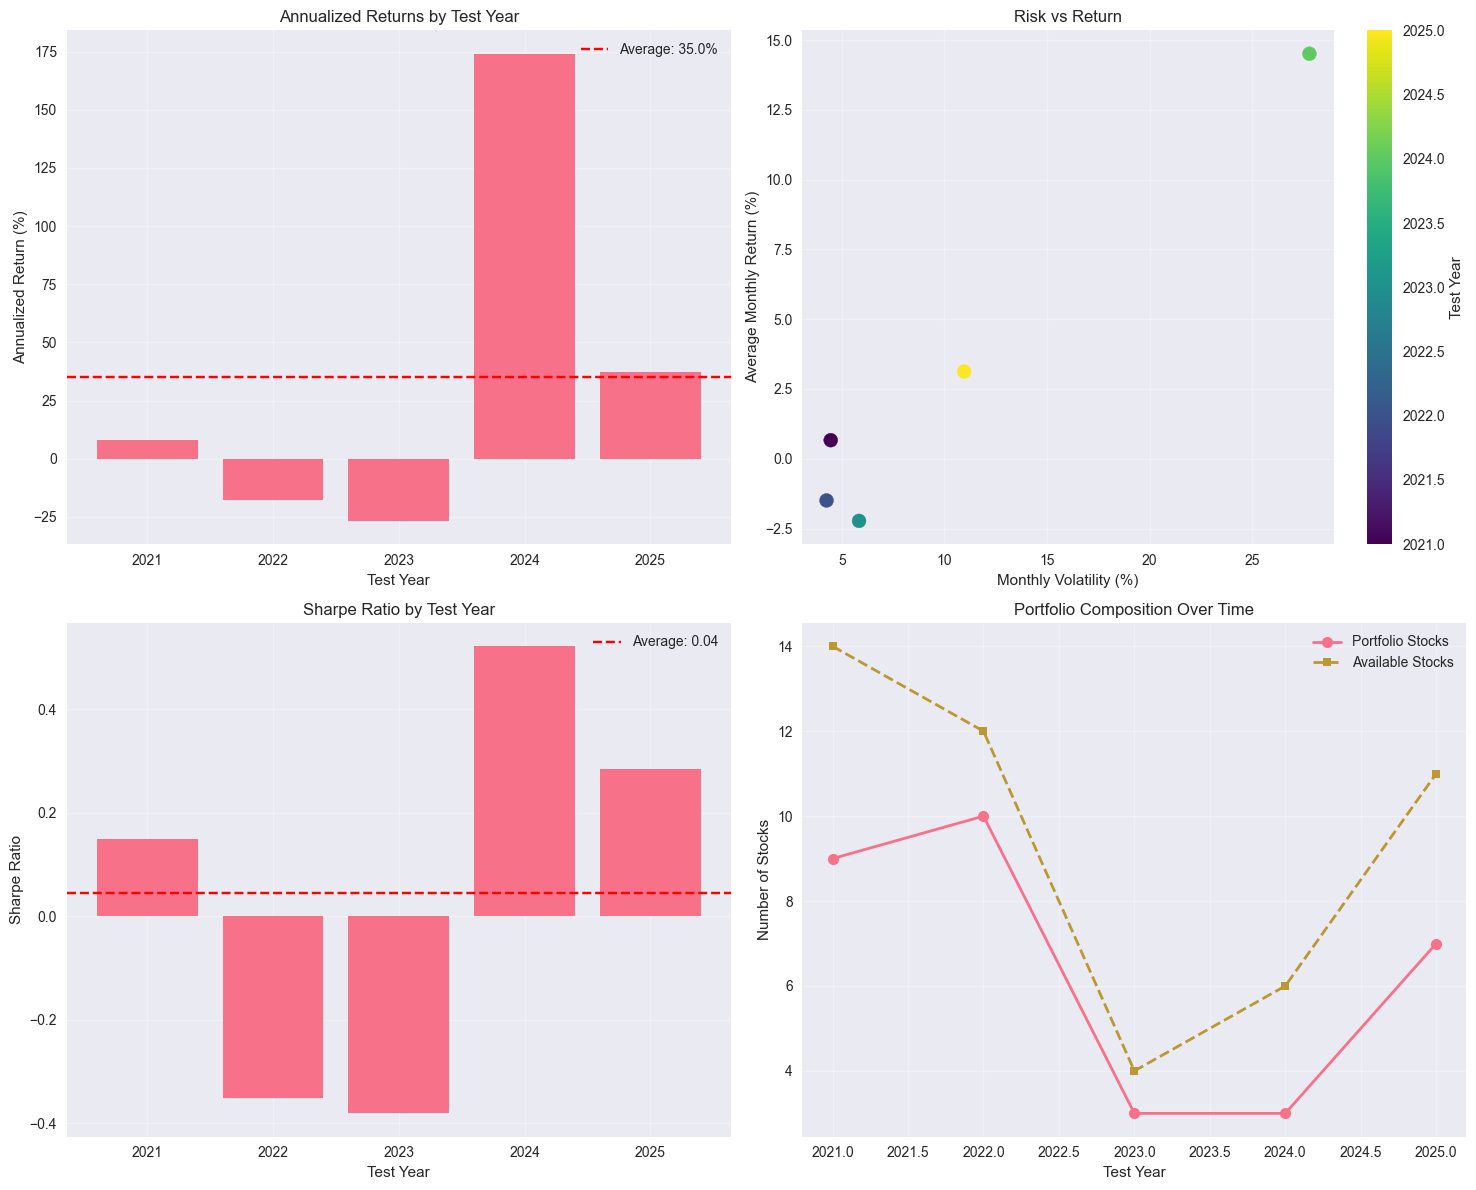


BACKTESTING SUMMARY STATISTICS

PERFORMANCE METRICS:
Average Annual Return: 34.98%
Average Monthly Volatility: 10.66%
Average Sharpe Ratio: 0.045
Best Year Return: 174.11% (2024)
Worst Year Return: -26.72% (2023)

PORTFOLIO CHARACTERISTICS:
Average Portfolio Size: 6.4 stocks
Average Available Stocks: 9.4 stocks
Portfolio Utilization: 68.1%

RISK METRICS:
Return Volatility: 81.70%
Success Rate (positive returns): 60.0%


In [10]:
# Run the complete backtesting analysis
print("Starting comprehensive backtesting analysis...")
print(f"Testing years: {CONFIG['test_start_year']} to {CONFIG['test_end_year']}")

# Run backtesting
results_df = run_backtesting(CONFIG['test_start_year'], CONFIG['test_end_year'])

if len(results_df) > 0:
    print(f"\nBacktesting completed! Results for {len(results_df)} years.")
    
    # Display results table
    display_df = results_df.copy()
    display_df['Avg_Monthly_Return'] = display_df['Avg_Monthly_Return'] * 100
    display_df['Total_Return'] = display_df['Total_Return'] * 100
    display_df['Volatility'] = display_df['Volatility'] * 100
    
    print("\nDetailed Results:")
    print(display_df.round(2).to_string(index=False))
    
    # Show visualizations
    if CONFIG['show_plots']:
        plot_backtesting_results(results_df)
    
else:
    print("No successful backtesting results obtained.")
    print("Please check your configuration parameters and data availability.")

## Current Portfolio Creation (Optional)

Create a portfolio for the current year using the latest available data.

In [11]:
# Create current portfolio
print("\n" + "="*60)
print("CREATING CURRENT DIVIDEND-FOCUSED PORTFOLIO")
print("="*60)

try:
    # Determine which stock universe to use
    if CONFIG['use_dividend_filter'] and len(HIGH_DIVIDEND_STOCKS) > 0:
        current_stock_universe = HIGH_DIVIDEND_STOCKS
        print(f"Using dividend-filtered stocks: {len(current_stock_universe)} stocks")
        portfolio_type = "Dividend"
    else:
        current_stock_universe = INDONESIA_BLUECHIP
        print(f"Using all blue chip stocks: {len(current_stock_universe)} stocks")
        portfolio_type = "Standard"
    
    # Get recent data for current portfolio
    current_start = f"{CONFIG['current_year']-2}-01-01"
    current_end = f"{CONFIG['current_year']-1}-12-31"
    
    current_returns = get_stock_data(current_stock_universe, current_start, current_end)
    
    if len(current_returns) > 0:
        # Filter positive return stocks
        current_positive_stocks = filter_positive_returns(current_returns)
        
        if len(current_positive_stocks) >= 2:
            current_filtered_returns = current_returns[current_positive_stocks]
            
            # Optimize current portfolio
            current_weights, current_stats = optimize_portfolio(current_filtered_returns)
            
            # Create current allocation
            current_allocation = create_portfolio_allocation(
                current_weights, current_positive_stocks, CONFIG['initial_capital']
            )
            
            print(f"\nCurrent {portfolio_type} Portfolio Allocation:")
            display_allocation = current_allocation.copy()
            display_allocation['Weight'] = display_allocation['Weight'].round(4)
            display_allocation['Actual_Weight'] = display_allocation['Actual_Weight'].round(4)
            print(display_allocation.to_string(index=False))
            
            # Save current portfolio
            if CONFIG['save_results']:
                output_dir = CONFIG['output_folder']
                if not os.path.exists(output_dir):
                    os.makedirs(output_dir)
                
                filename = f'{output_dir}/Current_{portfolio_type}_Portfolio_{CONFIG["current_year"]}.csv'
                current_allocation.to_csv(filename, index=False)
                print(f"\nCurrent {portfolio_type.lower()} portfolio saved to {filename}")
                
                # Also save dividend analysis summary if using dividend filter
                if CONFIG['use_dividend_filter'] and len(HIGH_DIVIDEND_STOCKS) > 0:
                    summary_data = {
                        'Total_Stocks_Analyzed': len(INDONESIA_BLUECHIP),
                        'High_Dividend_Stocks': len(HIGH_DIVIDEND_STOCKS),
                        'Min_Dividend_Yield': CONFIG['min_dividend_yield'],
                        'Analysis_Period_Years': CONFIG['dividend_years_back'],
                        'Portfolio_Stocks': len(current_allocation),
                        'Expected_Monthly_Return': current_stats['expected_return'],
                        'Expected_Monthly_Risk': current_stats['risk'],
                        'Sharpe_Ratio': current_stats['sharpe_ratio']
                    }
                    
                    summary_df = pd.DataFrame([summary_data])
                    summary_df.to_csv(f'{output_dir}/Dividend_Analysis_Summary_{CONFIG["current_year"]}.csv', index=False)
                    print(f"Dividend analysis summary saved to {output_dir}/")
        
        else:
            print(f"Insufficient stocks with positive returns for current {portfolio_type.lower()} portfolio")
    else:
        print("No current data available for portfolio creation")
        
except Exception as e:
    print(f"Error creating current portfolio: {e}")


CREATING CURRENT DIVIDEND-FOCUSED PORTFOLIO
Using dividend-filtered stocks: 18 stocks
Successfully downloaded 18 stocks
Filtered to 14 stocks with positive returns
Portfolio optimized successfully!
Expected monthly return: 2.128%
Monthly risk (volatility): 3.136%
Sharpe ratio: 0.678

Portfolio Allocation:
Total capital: IDR 20,000,000
Total invested: IDR 17,441,900
Cash remaining: IDR 2,558,100
Utilization: 87.2%

Current Dividend Portfolio Allocation:
  Stock  Weight  Target_Value  Price_Per_Share  Price_Per_Lot  Lots  Actual_Value  Actual_Weight
BMRI.JK  0.0755  1.509797e+06           4770.0       477000.0     3     1431000.0         0.0716
BNGA.JK  0.3195  6.389506e+06           1720.0       172000.0    37     6364000.0         0.3182
ASII.JK  0.0576  1.152239e+06           5025.0       502500.0     2     1005000.0         0.0503
PGAS.JK  0.1474  2.948425e+06           1625.0       162500.0    18     2925000.0         0.1462
ITMG.JK  0.2122  4.243601e+06          23025.0      23025

## Configuration Tips and Next Steps

### How to Adjust Parameters:

#### Dividend Filtering:
1. **Enable/Disable Dividend Filter**: Set `use_dividend_filter` to True/False
2. **Adjust Dividend Threshold**: Change `min_dividend_yield` (e.g., 0.05 for 5%, 0.08 for 8%)
3. **Change Analysis Period**: Modify `dividend_years_back` (e.g., 3 for 3 years, 7 for 7 years)

#### Portfolio Settings:
4. **Change Testing Period**: Modify `test_start_year` and `test_end_year` in CONFIG
5. **Adjust Capital**: Change `initial_capital` for different investment amounts
6. **Risk Tolerance**: Adjust `max_weight_per_stock` to limit concentration
7. **Return Requirements**: Set `min_mean_return` to filter stocks
8. **Data Period**: Modify `training_period_months` for optimization window

#### Output Settings:
9. **Change Output Location**: Modify `output_folder` to save results elsewhere
10. **Enable/Disable Saving**: Set `save_results` to True/False

### Dividend-Focused Improvements:

- **Dividend Growth Analysis**: Add dividend growth rate filtering
- **Dividend Sustainability**: Include payout ratio analysis
- **Sector Diversification**: Ensure dividend stocks across multiple sectors
- **Dividend Aristocrats**: Focus on stocks with long dividend payment history
- **Yield vs Growth Balance**: Optimize between current yield and dividend growth

### Performance Improvements:

- Add transaction costs
- Include dividend reinvestment strategies
- Implement quarterly rebalancing
- Add more sophisticated risk measures
- Include market timing filters
- Consider tax implications of dividend income

### Data Quality and Dividend Analysis:

- Monitor dividend data availability and accuracy
- Handle special dividends vs regular dividends
- Consider ex-dividend date timing
- Validate dividend yield calculations
- Handle stock splits and dividend adjustments
- Cross-reference with official company reports

### Expected Outcomes:

With dividend filtering enabled, you can expect:
- **Lower Portfolio Volatility**: Dividend-paying stocks tend to be more stable
- **Regular Income Stream**: Portfolio generates consistent dividend income
- **Quality Companies**: Focus on financially stable, profitable companies
- **Inflation Protection**: Dividends often grow with inflation
- **Risk-Adjusted Returns**: Better risk-adjusted performance during market downturns

### Troubleshooting:

- If no stocks pass dividend filter: Lower `min_dividend_yield` or reduce `dividend_years_back`
- If dividend data is missing: Check stock ticker symbols and data availability
- If performance is poor: Consider relaxing dividend criteria or adding growth stocks